In [1]:
import myosuite
import gym
import skvideo.io
import numpy as np
import os
import imageio
import tqdm
import time
from IPython.display import HTML
from base64 import b64encode
import matplotlib.pyplot as plt


MyoSuite:> Registering Myo Envs


In [2]:

def show_video(video_path, video_width = 400):

  video_file = open(video_path, "r+b").read()

  video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
  return HTML(f"""<video autoplay width={video_width} controls><source src="{video_url}"></video>""")

In [3]:
from stable_baselines3 import PPO

env = gym.make('CenterReachOut-v0')

pygame 2.5.2 (SDL 2.28.3, Python 3.8.18)
Hello from the pygame community. https://www.pygame.org/contribute.html
    MyoSuite: A contact-rich simulation suite for musculoskeletal motor control
        Vittorio Caggiano, Huawei Wang, Guillaume Durandau, Massimo Sartori, Vikash Kumar
        L4DC-2019 | https://sites.google.com/view/myosuite
    


In [ ]:
#model = PPO.load("test", env=env, device="cpu")

In [4]:
import pickle
# load policy

policy = "./policies/seed_42/best_policy.pickle"
pi = pickle.load(open(policy, 'rb'))

[-0.2312 -0.4009  1.07  ]
OrderedDict([('reach', array(-0.4096)), ('vel', array(-0.0016)), ('bonus', array(0.)), ('act', array(-0.0148)), ('sparse', array(-0.4096)), ('solved', array(0.)), ('done', array(False)), ('dense', -0.42518846994355725)])
[0.]
0.0
OrderedDict([('reach', array(-0.1588)), ('vel', array(-0.0105)), ('bonus', array(0.)), ('act', array(-0.0624)), ('sparse', array(-0.1588)), ('solved', array(0.)), ('done', array(False)), ('dense', -0.2264084720384999)])
[0.02]
0.19371736387279123
OrderedDict([('reach', array(-0.1508)), ('vel', array(-0.0054)), ('bonus', array(0.)), ('act', array(-0.0812)), ('sparse', array(-0.1508)), ('solved', array(0.)), ('done', array(False)), ('dense', -0.23473515180371557)])
[0.04]
0.24588998734489217
OrderedDict([('reach', array(-0.145)), ('vel', array(-0.0009)), ('bonus', array(0.)), ('act', array(-0.089)), ('sparse', array(-0.145)), ('solved', array(0.)), ('done', array(False)), ('dense', -0.23446313513657316)])
[0.06]
0.3258422415376757
Order

c:\Users\Elyas\anaconda3\envs\myosuite\lib\site-packages\ipywidgets\widgets\widget.py:503: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


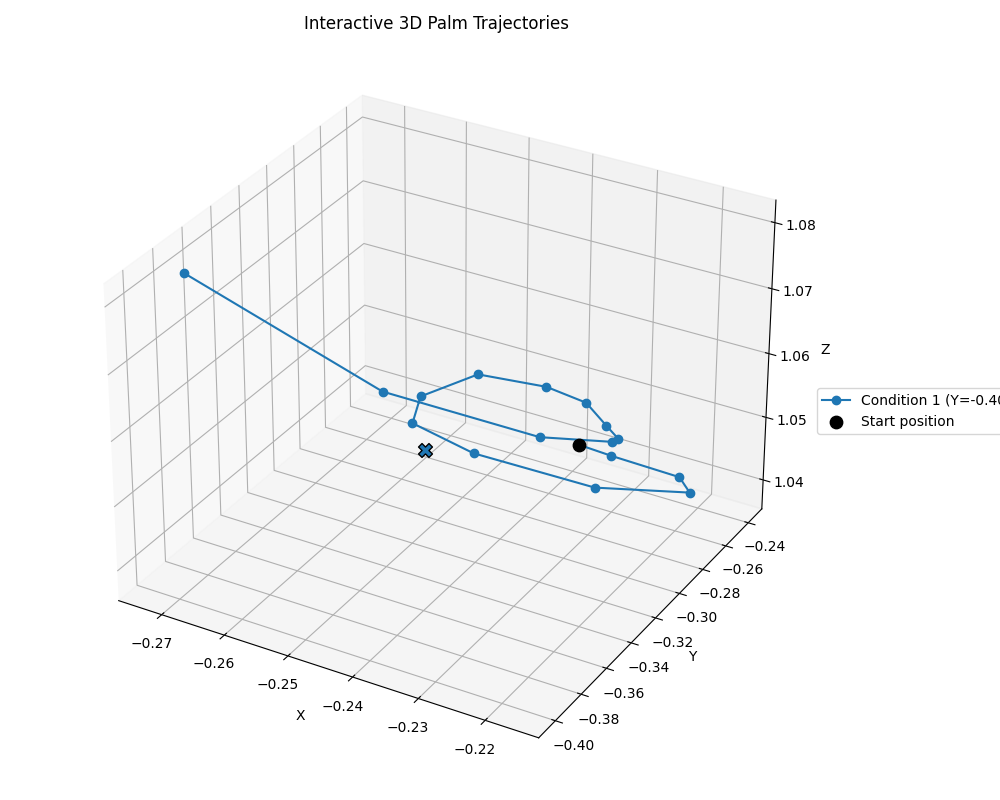

In [ ]:
%matplotlib widget

from time import sleep
import os
import torch
import imageio
import matplotlib.pyplot as plt
import numpy as np
import gym
from matplotlib.patches import Circle
import matplotlib.cm as cm

env = gym.make('CenterReachOut-v0')
frames = []

# Data containers
TotalPalmTrajectories = {}  # NEW: Store palm trajectory per condition
ObjectPositions = {}

total_reward = 0
num_samples = 1
ep_num = 0


for x in range(num_samples):
    conditions = {}

    for n in range(120):  # Number of episodes
        obs = env.reset()
        condition = env.obs_dict['obj_pos'][1]  # Use Y position as condition ID
        
        if condition in conditions:
            continue

        if len(conditions) == 8:
            break

        conditions[condition] = 1

        obj_pos = np.copy(env.obs_dict['obj_pos'])
        ObjectPositions[condition] = obj_pos

        palm_traj = []  # NEW: trajectory of palm_pos over time
        
        print(env.obs_dict['obj_pos'])
        
        velocities = [] 
        
        for ac_num in range(17):  # 16 steps
            hand_qvel = np.copy(env.obs_dict['hand_qvel'])  # shape (n_joints,)
            vel_mag = np.linalg.norm(hand_qvel)
            velocities.append(vel_mag)
            
            print(env.rwd_dict)

            frame = env.sim.renderer.render_offscreen(
                width=400,
                height=400,
                camera_id=1
            )
            frames.append(frame)

            o = env.get_obs()
            #action, _ = model.predict(o)  
            action, _ = pi.get_action(o)

            
            
            print(env.obs_dict['time'] )
            print(np.linalg.norm(env.obs_dict['hand_qvel']))

            # Record palm position (x, y)
            palm_pos_3d = np.copy(env.obs_dict['palm_pos'])
            palm_traj.append(palm_pos_3d)

            obs, reward, done, info = env.step(action)
            total_reward += reward

        # Store trajectory
        TotalPalmTrajectories[condition] = np.array(palm_traj)

        ep_num += 1

print(env.rwd_dict)


env.close()

os.makedirs('videos', exist_ok=True)
video_path = 'videos/test_traj.mp4'
# make a local copy
imageio.mimsave(video_path, frames, fps=10)
show_video('videos/test_traj.mp4')


num_conditions = len(TotalPalmTrajectories)
colors = cm.get_cmap('tab10', num_conditions)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

num_conditions = len(TotalPalmTrajectories)
colors = cm.get_cmap('tab10', num_conditions)

for i, (cond, traj) in enumerate(TotalPalmTrajectories.items()):
    color = colors(i)
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2],
            color=color, label=f'Condition {i+1} (Y={cond:.2f})', marker='o')

    obj_pos = ObjectPositions[cond]
    ax.scatter(obj_pos[0], obj_pos[1], obj_pos[2],
               color=color, marker='X', s=100, edgecolor='k', label=None)

# Start position
start_pos = list(TotalPalmTrajectories.values())[0][0]
ax.scatter(start_pos[0], start_pos[1], start_pos[2], c='black', s=80, marker='o', label='Start position')

# Formatting
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Interactive 3D Palm Trajectories")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

c:\Users\Elyas\anaconda3\envs\myosuite\lib\site-packages\ipywidgets\widgets\widget.py:503: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


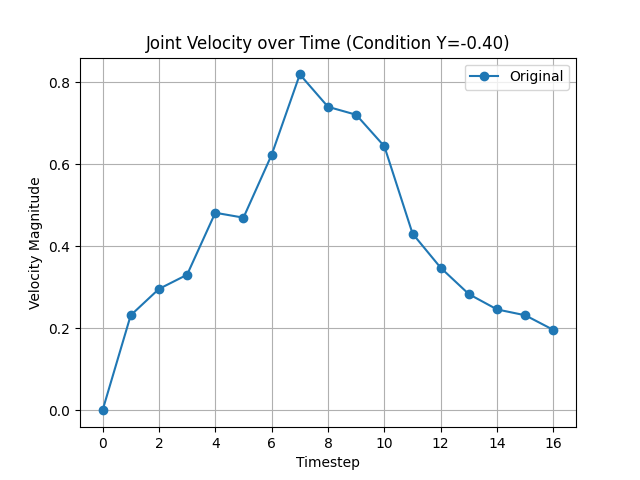

In [6]:
from scipy.optimize import curve_fit

timesteps = np.arange(len(velocities))

plt.figure()
plt.plot(timesteps, velocities, 'o-', label='Original')
plt.xlabel('Timestep')
plt.ylabel('Velocity Magnitude')
plt.title(f'Joint Velocity over Time (Condition Y={condition:.2f})')
plt.legend()
plt.grid(True)
plt.show()